In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [4]:
from ml.src.train import generate_training_data

df = generate_training_data()
print(f'Dataset shape: {df.shape}')
df.head()

ModuleNotFoundError: No module named 'ml.src'

In [5]:
from app.ml.preprocessing.skill_extractor import extract_skills
from app.ml.preprocessing.text_cleaner import extract_experience_years

df['resume_skills'] = df['resume'].apply(extract_skills)
df['job_skills'] = df['job'].apply(extract_skills)
df['resume_skill_count'] = df['resume_skills'].apply(len)
df['job_skill_count'] = df['job_skills'].apply(len)
df['experience_years'] = df['resume'].apply(extract_experience_years)

print(df[['resume_skill_count','job_skill_count','experience_years','label']].describe())

ModuleNotFoundError: No module named 'app'

NameError: name 'df' is not defined

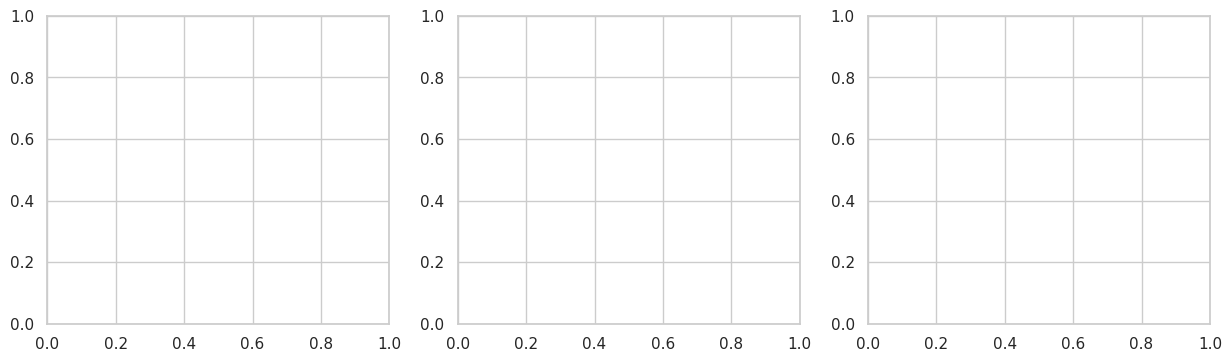

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
counts = df['label'].value_counts()
axes[0].bar(['No Match','Match'], counts.values, color=['#e74c3c','#2ecc71'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

# Skill count by label
df.groupby('label')[['resume_skill_count','job_skill_count']].mean().plot(
    kind='bar', ax=axes[1], color=['#3498db','#e67e22']
)
axes[1].set_title('Avg Skill Count by Label')
axes[1].set_xticklabels(['No Match','Match'], rotation=0)

# Experience by label
df.groupby('label')['experience_years'].mean().plot(
    kind='bar', ax=axes[2], color=['#e74c3c','#2ecc71']
)
axes[2].set_title('Avg Experience by Label')
axes[2].set_xticklabels(['No Match','Match'], rotation=0)

plt.tight_layout()
plt.show()
print('EDA Complete ✅')